# Dataset Validation

This notebook verifies:

1. Experimental design (block vs interleaved)
2. Frequency content (presence of alpha and beta bands)
3. Sampling rate consistency
4. Dataset integrity across subjects

In [1]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.signal import welch

# notebook is in notebooks/, so go up one level to find Preprocessed/
base_path = os.path.dirname(os.getcwd())
data_folder = os.path.join(base_path, "Preprocessed")

files = sorted([f for f in os.listdir(data_folder) if f.endswith(".mat")])
print("Found", len(files), "subject files")
print("Example:", files[:3])

Found 18 subject files
Example: ['S10_preprocessed.mat', 'S11_preprocessed.mat', 'S12_preprocessed.mat']


# Experimental Design Validation (Block vs. Interleaved)

A critical requirement for this project is ensuring we are not analyzing a Block Design. For example, Block Design would occur if the stimuli were grouped (e.g., all Music Cello trials first, then all Speech).

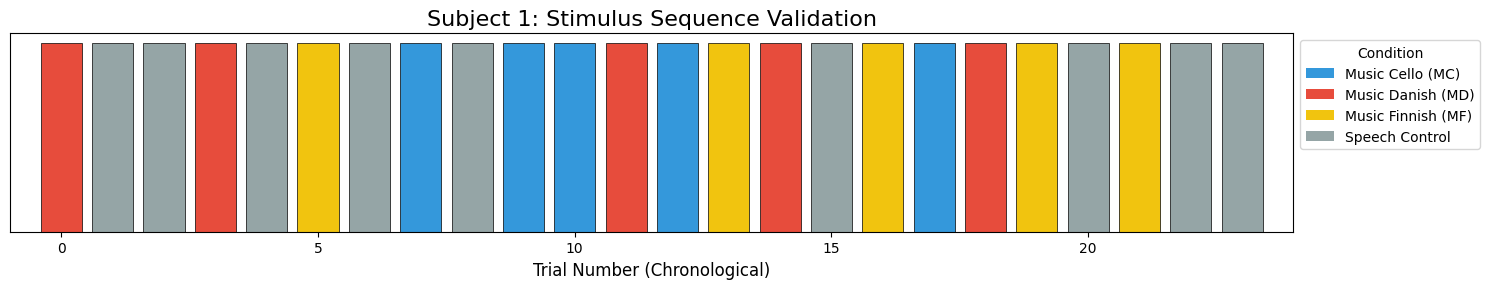

Found 4 distinct conditions.
Total Trials: 24
Consecutive Repeated Conditions: 3
PASSED: Design appears to be interleaved/randomized.


In [2]:
# Load a representative subject (Subject 1)
sample_subject = os.path.join(data_folder, 'S1_preprocessed.mat')
mat = scipy.io.loadmat(sample_subject)
all_trials = mat['Data'][0, 0]['data'][0]

# Extract the sequence of condition labels
raw_sequence = [t['TargetType'][0] for t in all_trials]

# Map to clean categories
# MC=Cello, MD=Danish, MF=Finnish, S=Speech
audit_map = []
for label in raw_sequence:
    if 'MC' in label: audit_map.append('Music Cello (MC)')
    elif 'MD' in label: audit_map.append('Music Danish (MD)')
    elif 'MF' in label: audit_map.append('Music Finnish (MF)')
    else: audit_map.append('Speech Control')

# VISUAL AUDIT: Timeline of Stimulus Presentation

plt.figure(figsize=(15, 3))
colors = {'Music Cello (MC)': '#3498db', 'Music Danish (MD)': '#e74c3c', 
          'Music Finnish (MF)': '#f1c40f', 'Speech Control': '#95a5a6'}

for i, cond in enumerate(audit_map):
    plt.bar(i, 1, color=colors[cond], width=0.8, edgecolor='black', linewidth=0.5)

plt.title("Subject 1: Stimulus Sequence Validation", fontsize=16)
plt.xlabel("Trial Number (Chronological)", fontsize=12)
plt.yticks([]) # Clean up Y axis
plt.xlim(-1, len(audit_map))

# Add Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=k) for k in colors]
plt.legend(handles=legend_elements, bbox_to_anchor=(1, 1), loc='upper left', title="Condition")

plt.tight_layout()
plt.show()

# overall validation for subj 1
consecutive_matches = sum(1 for i in range(len(audit_map)-1) if audit_map[i] == audit_map[i+1])
print(f"Found {len(set(audit_map))} distinct conditions.")
print(f"Total Trials: {len(audit_map)}")
print(f"Consecutive Repeated Conditions: {consecutive_matches}")

if consecutive_matches < (len(audit_map) / 2):
    print("PASSED: Design appears to be interleaved/randomized.")
else:
    print("WARNING: Seems to be a High number of consecutive conditions detected.")

### Quantitative Check: Run Lengths + Transition Rate (Block vs Interleaved)

In [3]:
labels = audit_map


# ---- Run-lengths (consecutive repeats) ----
runs = []
current = labels[0]
length = 1

for lab in labels[1:]:
    if lab == current:
        length += 1
    else:
        runs.append((current, length))
        current = lab
        length = 1

runs.append((current, length))

max_run = max(r[1] for r in runs)
num_repeats = sum((r[1] - 1) for r in runs)  # total extra repeats beyond first in each run

print("Total trials:", len(labels))
print("Max run length:", max_run)
print("Total consecutive repeats:", num_repeats)
print("Runs (label, length):", runs)

# ---- Transition rate ----
transitions = sum(labels[i] != labels[i+1] for i in range(len(labels) - 1))
transition_rate = transitions / (len(labels) - 1)

print("Transitions:", transitions)
print("Transition rate:", transition_rate)

# ---- interpretation ----
if max_run >= 6:
    print("⚠️ Looks more like BLOCKING (long consecutive runs detected).")
elif max_run <= 3 and transition_rate >= 0.6:
    print("✅ Looks INTERLEAVED / randomized (short runs + high switching).")
else:
    print("🟡 Mixed: not strongly blocked, but not highly interleaved either.")

Total trials: 24
Max run length: 2
Total consecutive repeats: 3
Runs (label, length): [('Music Danish (MD)', 1), ('Speech Control', 2), ('Music Danish (MD)', 1), ('Speech Control', 1), ('Music Finnish (MF)', 1), ('Speech Control', 1), ('Music Cello (MC)', 1), ('Speech Control', 1), ('Music Cello (MC)', 2), ('Music Danish (MD)', 1), ('Music Cello (MC)', 1), ('Music Finnish (MF)', 1), ('Music Danish (MD)', 1), ('Speech Control', 1), ('Music Finnish (MF)', 1), ('Music Cello (MC)', 1), ('Music Danish (MD)', 1), ('Music Finnish (MF)', 1), ('Speech Control', 1), ('Music Finnish (MF)', 1), ('Speech Control', 2)]
Transitions: 20
Transition rate: 0.8695652173913043
✅ Looks INTERLEAVED / randomized (short runs + high switching).


## Frequency Content Validation (Alpha and Beta Bands)

We verify that the EEG signal contains expected spectral content:

- Alpha band: 8–12 Hz
- Beta band: 13–30 Hz

Power spectral density (PSD) is computed using Welch’s method to confirm the presence of these frequency components.

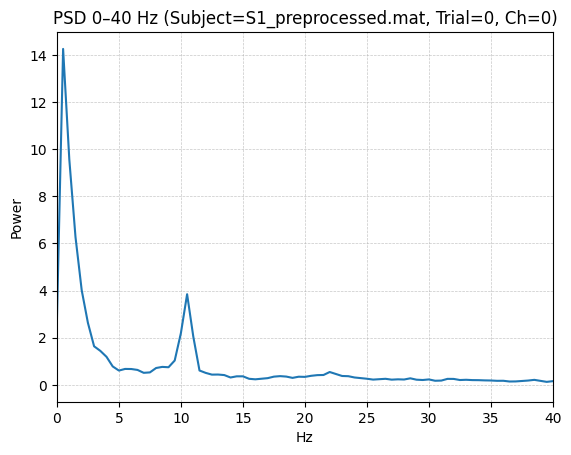

Alpha mean power: 1.3865697
Beta mean power: 0.32079062
Beta/Alpha ratio: 0.23135556


In [8]:
SUBJECT_FILE = "S1_preprocessed.mat"   
TRIAL_IDX = 0
CH_IDX = 0

sample_path = os.path.join(data_folder, SUBJECT_FILE)
mat = scipy.io.loadmat(sample_path)

trials = mat["Data"][0,0]["data"][0]
trial = trials[TRIAL_IDX]

eeg = trial["EEG"]         # shape (64, N)
ch = eeg[CH_IDX]

info = mat["Data"][0,0]["info"][0,0]
fs = float(info["EEG_fs"][0,0])

f, Pxx = welch(ch, fs=fs, nperseg=int(fs*2))

plt.figure()
plt.plot(f, Pxx)
plt.xlim(0, 40)
plt.xlabel("Hz")
plt.ylabel("Power")
plt.title(f"PSD 0–40 Hz (Subject={SUBJECT_FILE}, Trial={TRIAL_IDX}, Ch={CH_IDX})")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
plt.show()

alpha = Pxx[(f >= 8) & (f <= 12)].mean()
beta  = Pxx[(f >= 13) & (f <= 30)].mean()

print("Alpha mean power:", alpha)
print("Beta mean power:", beta)
print("Beta/Alpha ratio:", beta/alpha)

## Sampling Rate Consistency Across Subjects

We verify that all subjects were recorded at the same EEG sampling rate (EEG_fs).

Inconsistent sampling rates would require resampling prior to analysis.

In [5]:
fs_list = []
for fname in files:
    m = scipy.io.loadmat(os.path.join(data_folder, fname))
    info = m["Data"][0,0]["info"][0,0]
    fs_list.append(float(info["EEG_fs"][0,0]))

fs_unique = sorted(set(fs_list))
print("Unique EEG_fs values:", fs_unique)
print("All same?", len(fs_unique) == 1)

Unique EEG_fs values: [512.0]
All same? True


## Dataset Integrity Checks

We verify that:

- All subject files load successfully
- Trial counts are consistent
- EEG arrays have expected dimensions
- Required trial fields are present

In [6]:
from collections import Counter

# ---------- helpers ----------
def map_condition(label):
    """Map raw TargetType strings to clean condition names."""
    label = str(label)
    if "MC" in label:
        return "Music Cello (MC)"
    if "MD" in label:
        return "Music Danish (MD)"
    if "MF" in label:
        return "Music Finnish (MF)"
    return "Speech Control"

def load_trials(mat_path):
    """Load trials array from one subject .mat file."""
    m = scipy.io.loadmat(mat_path)
    trials = m["Data"][0, 0]["data"][0]  # array of trial structs
    return trials, m

# ----------  Dataset integrity across subjects ----------
expected_trial_fields = {"TargetType", "EEG", "Engagement", "Familiarity", "Trial"}

issues = []              # hard issues (field mismatch, eeg shape weird, load failure)
trial_counts = []        # (fname, n_trials)
trial_count_by_file = {} # fname -> n_trials

for fname in files:  # assumes `files` and `data_folder` already exist from earlier cells
    fpath = os.path.join(data_folder, fname)
    try:
        trials, m = load_trials(fpath)

        # trial count
        n_trials = len(trials)
        trial_counts.append((fname, n_trials))
        trial_count_by_file[fname] = n_trials

        # structure checks
        fields = set(trials[0].dtype.names)
        if fields != expected_trial_fields:
            issues.append((fname, "trial fields mismatch", fields))

        eeg = trials[0]["EEG"]
        # EEG should be 2D and have 64 channels
        if not (isinstance(eeg, np.ndarray) and eeg.ndim == 2 and eeg.shape[0] == 64):
            shape = getattr(eeg, "shape", None)
            issues.append((fname, "EEG shape/type unexpected", type(eeg), shape))

    except Exception as e:
        issues.append((fname, "failed to load", str(e)))

# --- summary of hard issues ---
print("=== HARD ISSUES (should be 0) ===")
print("Count:", len(issues))
for item in issues[:20]:
    print(item)

# --- trial count summary ---
counts_only = [c for _, c in trial_counts]
unique_counts = sorted(set(counts_only))
mode_count = Counter(counts_only).most_common(1)[0][0]

print("\n=== TRIAL COUNT SUMMARY ===")
print("Subjects:", len(trial_counts))
print("Min trials:", min(counts_only))
print("Max trials:", max(counts_only))
print("Unique trial counts:", unique_counts)
print("Most common trial count (mode):", mode_count)

off_mode = [(f, c) for f, c in trial_counts if c != mode_count]
print("\nFiles not equal to mode:", len(off_mode))
for item in off_mode:
    print(item)

# --- condition distribution for the off-mode files ---
print("\n=== CONDITION COUNTS FOR OFF-MODE FILES ===")
for fname, n_trials in off_mode:
    fpath = os.path.join(data_folder, fname)
    trials, _ = load_trials(fpath)
    labels = [map_condition(t["TargetType"][0]) for t in trials]
    print(fname, "n=", n_trials, "counts=", dict(Counter(labels)))

=== HARD ISSUES (should be 0) ===
Count: 0

=== TRIAL COUNT SUMMARY ===
Subjects: 18
Min trials: 20
Max trials: 25
Unique trial counts: [20, 23, 24, 25]
Most common trial count (mode): 25

Files not equal to mode: 10
('S10_preprocessed.mat', 24)
('S11_preprocessed.mat', 24)
('S12_preprocessed.mat', 20)
('S13_preprocessed.mat', 24)
('S16_preprocessed.mat', 24)
('S1_preprocessed.mat', 24)
('S22_preprocessed.mat', 23)
('S2_preprocessed.mat', 20)
('S4_preprocessed.mat', 23)
('S8_preprocessed.mat', 24)

=== CONDITION COUNTS FOR OFF-MODE FILES ===
S10_preprocessed.mat n= 24 counts= {'Speech Control': 10, 'Music Finnish (MF)': 5, 'Music Cello (MC)': 5, 'Music Danish (MD)': 4}
S11_preprocessed.mat n= 24 counts= {'Speech Control': 9, 'Music Cello (MC)': 5, 'Music Danish (MD)': 5, 'Music Finnish (MF)': 5}
S12_preprocessed.mat n= 20 counts= {'Speech Control': 8, 'Music Cello (MC)': 4, 'Music Danish (MD)': 5, 'Music Finnish (MF)': 3}
S13_preprocessed.mat n= 24 counts= {'Music Finnish (MF)': 5, 'Mu

In [7]:
def map_condition(label):
    label = str(label)
    if "MC" in label: return "MC"
    if "MD" in label: return "MD"
    if "MF" in label: return "MF"
    return "S"

cond_counts_all = {}

for fname in files:
    fpath = os.path.join(data_folder, fname)
    m = scipy.io.loadmat(fpath)
    trials = m["Data"][0,0]["data"][0]
    labels = [map_condition(t["TargetType"][0]) for t in trials]
    cond_counts_all[fname] = Counter(labels)

# summarize average counts per condition
conds = ["MC","MD","MF","S"]
avg = {c: np.mean([cond_counts_all[f].get(c,0) for f in cond_counts_all]) for c in conds}
mins = {c: np.min([cond_counts_all[f].get(c,0) for f in cond_counts_all]) for c in conds}
maxs = {c: np.max([cond_counts_all[f].get(c,0) for f in cond_counts_all]) for c in conds}

print("Average trials per condition:", avg)
print("Min trials per condition:", mins)
print("Max trials per condition:", maxs)

Average trials per condition: {'MC': np.float64(4.833333333333333), 'MD': np.float64(4.888888888888889), 'MF': np.float64(4.722222222222222), 'S': np.float64(9.444444444444445)}
Min trials per condition: {'MC': np.int64(4), 'MD': np.int64(4), 'MF': np.int64(3), 'S': np.int64(7)}
Max trials per condition: {'MC': np.int64(5), 'MD': np.int64(5), 'MF': np.int64(5), 'S': np.int64(10)}
